
# Pneumonia Detection using Deep Learning (ResNet)

This project builds a deep learning model to detect pneumonia from chest X-rays using transfer learning (ResNet).  

**Final Results:**
- Accuracy: 86%
- F1 Score: 0.90
- Recall (Pneumonia): 99%


## 1. Setup & Imports

In [1]:
!pip install -q kaggle grad-cam

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 45.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
cuda


## 2. Download Dataset

In [2]:

# Upload kaggle.json before running

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d /content/data


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:18<00:00, 132MB/s]



## 3. Dataset Path

In [3]:

BASE_PATH = "/content/data/chest_xray/chest_xray"


## 4. Data Preprocessing

In [4]:

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


## 5. Data Loaders

In [5]:

train_data = datasets.ImageFolder(BASE_PATH + '/train', transform=transform)
val_data = datasets.ImageFolder(BASE_PATH + '/val', transform=transform)
test_data = datasets.ImageFolder(BASE_PATH + '/test', transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

print("Classes:", train_data.classes)


Classes: ['NORMAL', 'PNEUMONIA']


## 6. Handle Class Imbalance

In [6]:

labels = [label for _, label in train_data]
class_counts = Counter(labels)

weights = torch.tensor([1.0/class_counts[i] for i in range(len(class_counts))]).to(device)
print("Class Weights:", weights)


Class Weights: tensor([0.0007, 0.0003], device='cuda:0')


## 7. Model (ResNet Transfer Learning)

In [7]:

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


## 8. Loss & Optimizer

In [8]:

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.0001)


## 9. Training & Evaluation Functions

In [9]:

def train(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


## 10. Train Model

In [10]:

for epoch in range(5):
    loss = train(model, train_loader)
    val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Val Acc={val_acc:.4f}")


Epoch 1: Loss=0.1254, Val Acc=0.7500
Epoch 2: Loss=0.0714, Val Acc=0.9375
Epoch 3: Loss=0.0499, Val Acc=0.7500
Epoch 4: Loss=0.0348, Val Acc=0.6875
Epoch 5: Loss=0.0351, Val Acc=0.9375


## 11. Test Accuracy

In [11]:

test_acc = evaluate(model, test_loader)
print("Test Accuracy:", test_acc)


Test Accuracy: 0.8605769230769231


## 12. Detailed Evaluation

In [12]:

from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds))
print(confusion_matrix(all_labels, all_preds))


              precision    recall  f1-score   support

           0       0.98      0.63      0.77       234
           1       0.82      0.99      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.81      0.83       624
weighted avg       0.88      0.86      0.85       624

[[148  86]
 [  3 387]]


## 13. Grad-CAM Visualization

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

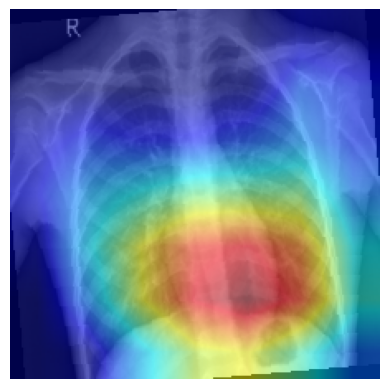

In [13]:

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layer = model.layer4[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

images, _ = next(iter(test_loader))
images = images.to(device)

grayscale_cam = cam(input_tensor=images)

img = images[0].cpu().permute(1,2,0).numpy()
img = (img - img.min()) / (img.max() - img.min())

cam_image = show_cam_on_image(img, grayscale_cam[0], use_rgb=True)

plt.imshow(cam_image)
plt.axis('off')
